Import all relevant libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Plot the prices distributrion

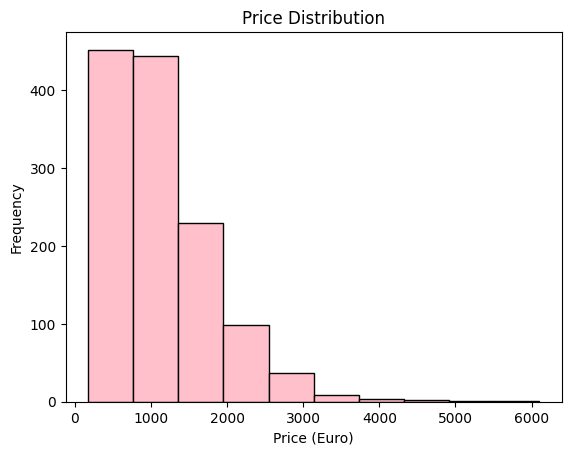

In [2]:
# Plot a histogram of one column distribution
def plot_column_histogram(dataset, column_name, axes_name, plot_name):
    plt.hist(dataset[column_name], color='pink', edgecolor='black')
    plt.xlabel(axes_name)
    plt.ylabel('Frequency')
    plt.title(plot_name)
    plt.show() 

laptop_data = pd.read_csv('laptop_price - dataset.csv')
price_column = 'Price (Euro)'

# Plot a histogram of all the prices
plot_column_histogram(laptop_data, price_column, price_column, 'Price Distribution')

Calculate the average laptop price for each company, and fing the most expensive one

In [3]:
company_column = 'Company'

# Find the average price per company 
avg_price_per_company = (laptop_data.groupby(company_column)[price_column]
                        .mean()
                        .sort_values(ascending=False))

# Find the most expensive company on average
most_expensive_company = avg_price_per_company.idxmax()

print('Most expensive company on average: ' + most_expensive_company)
print('Average prices per company:')
print(avg_price_per_company)

Most expensive company on average: Razer
Average prices per company:
Company
Razer        3346.142857
LG           2099.000000
MSI          1728.908148
Google       1677.666667
Microsoft    1612.308333
Apple        1564.198571
Huawei       1424.000000
Samsung      1413.444444
Toshiba      1267.812500
Dell         1199.225120
Xiaomi       1133.462500
Asus         1123.829737
Lenovo       1093.862215
HP           1080.314664
Fujitsu       729.000000
Acer          633.464455
Chuwi         314.296667
Mediacom      295.000000
Vero          217.425000
Name: Price (Euro), dtype: float64


Find the different operating system types

In [4]:
os_column = 'OpSys'

# Uniforming the OS types into a new column (to not override existing data)
laptop_data['UniformOpSys'] = laptop_data[os_column].replace({
    'Mac OS X': 'macOS',
    'Windows 10': 'Windows',
    'Windows 10 S': 'Windows',
    'Windows 7': 'Windows'
})

# Create a list of the unique values (OS types)
unique_os = laptop_data['UniformOpSys'].unique()

print('Operating system types:')
print(*unique_os, sep='\n')

Operating system types:
macOS
No OS
Windows
Linux
Android
Chrome OS


Show the price distribution for each OS in seperate plots 

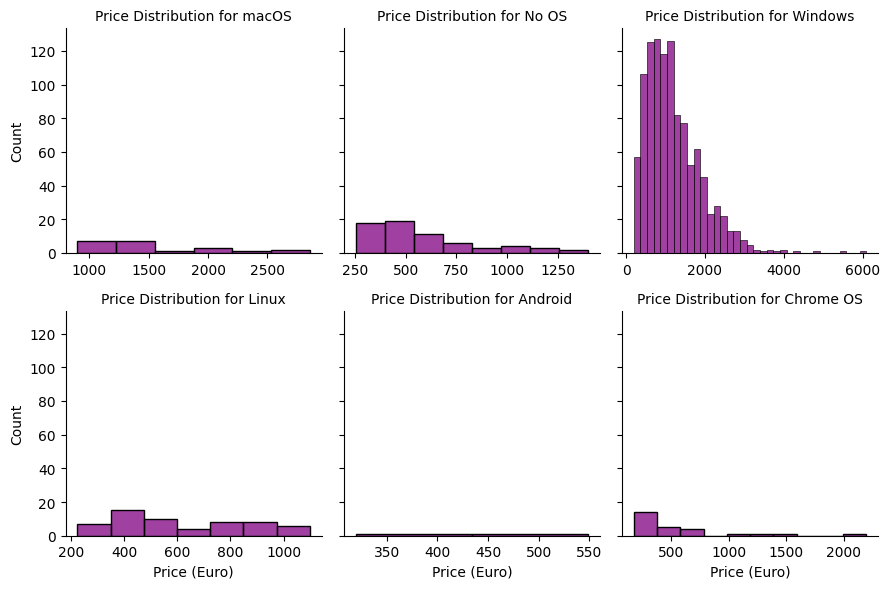

In [5]:
# Plot price distributions for each OS type
# Create a seperate histogram of the prices for each OS type 
subplots_grid = sns.FacetGrid(laptop_data, col='UniformOpSys', col_wrap=3, sharex=False)
subplots_grid.map_dataframe(sns.histplot, x=price_column, color='purple', edgecolor='black')
subplots_grid.set_axis_labels(price_column, 'Count')
subplots_grid.set_titles('Price Distribution for {col_name}')
plt.tight_layout()
plt.show()

Present the relationship between RAM and price using scatter plot with linear regression.

Correlation is calculated by pearson correlation and its coefficient is shown in the plot. 

After finding the relationship we find the price outliers using the IQR formula (price is a less "restricted" variable and its values can vary widely, unlike RAM which is very standartized)

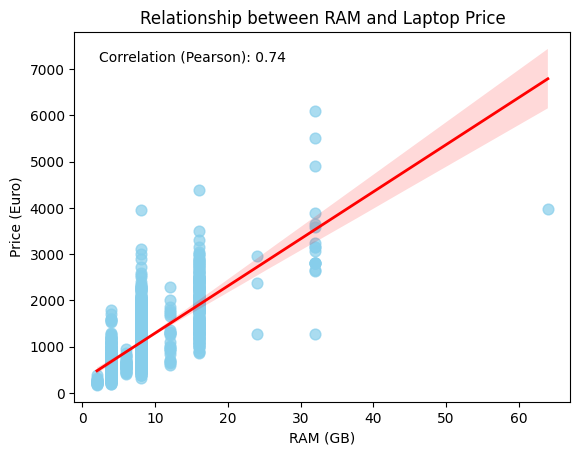

Price outliers:
     Company             Product     TypeName  Inches  \
17     Apple         MacBook Pro    Ultrabook    15.4   
196    Razer           Blade Pro       Gaming    17.3   
204     Dell      Precision 7520  Workstation    15.6   
238     Asus   ROG G703VI-E5062T       Gaming    17.3   
247     Asus  Rog G701VIK-BA060T       Gaming    17.3   
297     Dell      Precision 7720  Workstation    17.3   
517     Asus        ROG Zephyrus       Gaming    15.6   
530     Dell        Alienware 17       Gaming    17.3   
563   Lenovo        Thinkpad P71     Notebook    17.3   
610   Lenovo        Thinkpad P51     Notebook    15.6   
659     Dell        Alienware 17       Gaming    17.3   
723     Dell        Alienware 17       Gaming    17.3   
744   Lenovo       Thinkpad P51s  Workstation    15.6   
749       HP            Zbook 17  Workstation    17.3   
758     Dell        Alienware 17       Gaming    15.6   
778    Razer           Blade Pro       Gaming    14.0   
780     Dell   

In [6]:
# Detect a column outliers using IQR formula
def detect_iqr_outliers(dataset, column_name):
    q1 = dataset[column_name].quantile(0.25)
    q3 = dataset[column_name].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Filter the dataset for only outliers
    outliers = dataset[(dataset[column_name] < lower_bound) 
                       | (dataset[column_name] > upper_bound)]
    
    return outliers

ram_column = 'RAM (GB)'

# Show the relationship between RAM and price by scatter plot and regression line
# Starting by finding pearson correlation coefficient
correlation = laptop_data[ram_column].corr(laptop_data[price_column])

# Plot the relationship graph
plt.figure()
plt.text(
    0.05, 0.95,
    f'Correlation (Pearson): {correlation:.2f}',
    transform=plt.gca().transAxes,
    verticalalignment='top'
)
sns.regplot(x=ram_column, y=price_column, data=laptop_data, scatter_kws={'color':'skyblue', 's':60, 'alpha':0.7},
            line_kws={'color':'red', 'linewidth':2})
plt.xlabel(ram_column)
plt.ylabel(price_column)
plt.title('Relationship between RAM and Laptop Price')
plt.show()

# Calculate and show price outliers 
price_outliers = detect_iqr_outliers(laptop_data, price_column)

print('Price outliers:')
print(price_outliers)

Create a new column in the dataframe that contains the memory type for each laptop.

Memory type is found by filtering out the size for each type, trimming the strings left and joining multiple types to one string if it is relevant for the laptop.

In [7]:
memory_column = 'Memory'

# Create a new column with storage types by a regex filtering the memory size out
# If there are several memory types, join them together
laptop_data['Storage type'] = (
    laptop_data[memory_column]
    .str.extractall(r'\d+\s*(?:GB|TB)\s*([A-Za-z ]+)')[0]
    .str.strip()
    .groupby(level=0)
    .agg(' + '.join)                                       
)

print("Storage Types:")
print(*laptop_data['Storage type'].unique(), sep='\n')

Storage Types:
SSD
Flash Storage
HDD
SSD + HDD
SSD + SSD
Hybrid
Flash Storage + HDD
HDD + HDD
SSD + Hybrid
